<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/FashionMNIST_MLP_withhook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets  ## domain-specific library, include datasets
from torchvision.transforms import ToTensor

# Download FashionMNIST data

In [2]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), # convert to tensor and scale to [0,1]
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:09<00:00, 443kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]


The FashionMNIST dataset is a collection of 70,000 grayscale images of fashion articles, categorized into 10 classes. It serves as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. Each image is 28x28 pixels.

In [3]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

# Construct DataLoader

iterate over dataset, supports batching, shuffling etc.

In [5]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

# Explanation of the tensor shape:
# N (Batch Size): 64 images are processed in one batch.
# C (Channels): 1, indicating a grayscale image (one color channel).
# H (Height): 28 pixels.
# W (Width): 28 pixels.

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


# Create MLP model

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # hardware acceleration frameworks
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
        # Updated: Dictionary to store activations
        self.activations = {}
        self.history = {'weights': {}, 'gradients': {}, 'activations': {}}
        self._register_hooks()

    def _get_activation(self, name):
        # Updated: Hook function to capture output tensor
        def hook(model, input, output):
            self.activations[name] = input[0].detach() # creates a new view of the tensor that is separated from the current computational graph
            # Stop Gradient Tracking: Any operations performed on the detached tensor (like calculating mean or plotting) won't track gradients or affect the backpropagation of the model.
            # Memory Efficiency: If you store the raw output tensor in a list or dictionary, PyTorch keeps the entire computational graph (the history of every calculation) in memory. This can quickly lead to an 'Out of Memory' (OOM) error during training. Detaching allows the graph to be cleared after each batch while you keep just the numerical values.
            # Safety: It prevents accidental modifications to the original tensor that could interfere with the model's training process.
        return hook

    def _register_hooks(self):
        # Updated: Attach hooks to all RELU layers to monitor activations
        for name, layer in self.linear_relu_stack.named_children(): #Only iterates over the immediate sub-modules, not recursive diving deeper
            if isinstance(layer, nn.ReLU):
                layer.register_forward_hook(self._get_activation(f"layer_{name}"))

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

    # Updated: Record the statistics during training (per epoch)
    def record_stats(self):
        # Record Weight and Gradient stats
        for name, param in self.named_parameters():
            if 'weight' in name:
                if name not in self.history['weights']:
                    self.history['weights'][name] = []
                    self.history['gradients'][name] = []
                self.history['weights'][name].append(param.data.cpu().numpy().flatten())
                if param.grad is not None:
                    self.history['gradients'][name].append(param.grad.data.cpu().numpy().flatten())

        # Record Activation stats
        for name, act in self.activations.items():
            if name not in self.history['activations']:
                self.history['activations'][name] = []
            self.history['activations'][name].append(act.cpu().numpy().flatten())

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


# Model training and testing

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [13]:
def train(dataloader, model, loss_fn, optimizer, epoch_idx):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()

        # Record stats BEFORE zeroing gradients (only on the last batch of the epoch)
        if batch == len(dataloader) - 1:
            model.record_stats()

        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [14]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [15]:

# Re-initializing model to clear history and start fresh from initial random states
model = NeuralNetwork().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

epochs = 10 # Reduced for demonstration
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer, t)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.285388  [   64/60000]
loss: 2.276039  [ 6464/60000]
loss: 2.257461  [12864/60000]
loss: 2.269512  [19264/60000]
loss: 2.242733  [25664/60000]
loss: 2.198366  [32064/60000]
loss: 2.224267  [38464/60000]
loss: 2.174256  [44864/60000]
loss: 2.168154  [51264/60000]
loss: 2.142734  [57664/60000]
Test Error: 
 Accuracy: 37.3%, Avg loss: 2.133579 

Epoch 2
-------------------------------
loss: 2.135851  [   64/60000]
loss: 2.126269  [ 6464/60000]
loss: 2.065525  [12864/60000]
loss: 2.092431  [19264/60000]
loss: 2.027769  [25664/60000]
loss: 1.951181  [32064/60000]
loss: 1.996712  [38464/60000]
loss: 1.901359  [44864/60000]
loss: 1.909654  [51264/60000]
loss: 1.827517  [57664/60000]
Test Error: 
 Accuracy: 53.3%, Avg loss: 1.832405 

Epoch 3
-------------------------------
loss: 1.868253  [   64/60000]
loss: 1.834729  [ 6464/60000]
loss: 1.715677  [12864/60000]
loss: 1.765252  [19264/60000]
loss: 1.638515  [25664/60000]
loss: 1.594177  [32064/600

# Visualization of Training Dynamics
We will now plot the distributions of weights, gradients, and activations to see how they evolve over time.

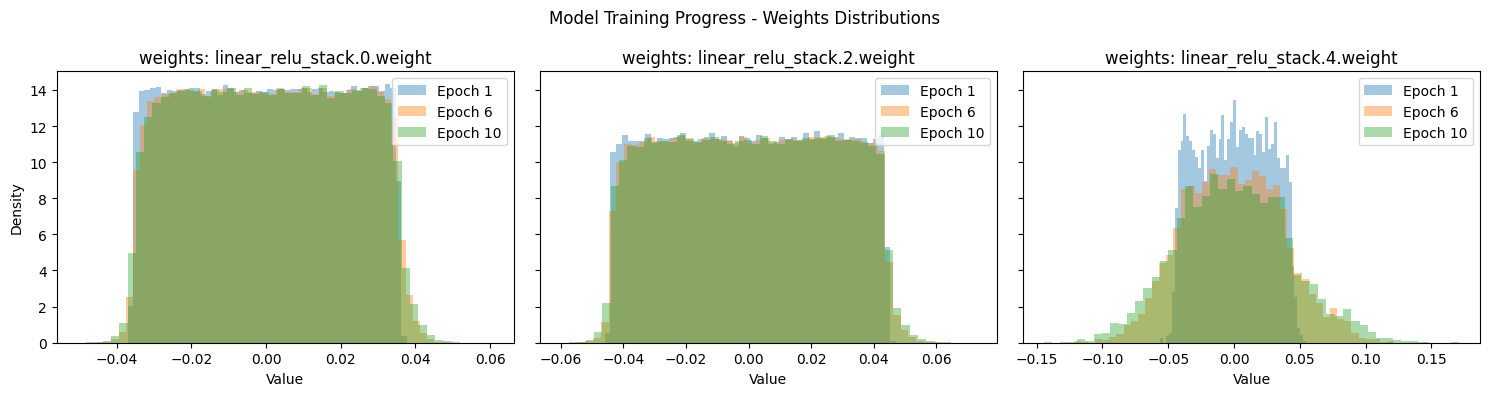

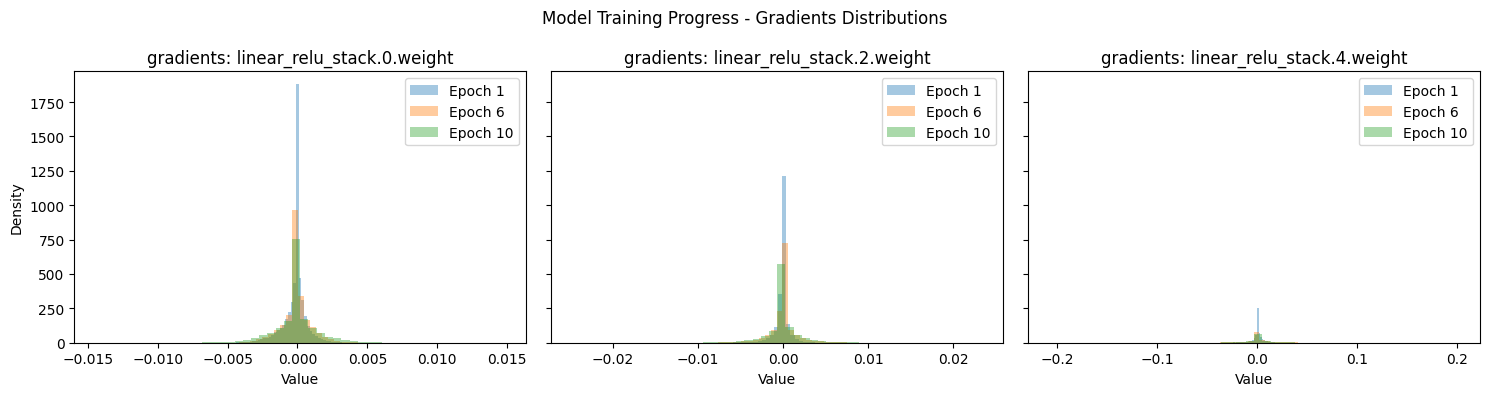

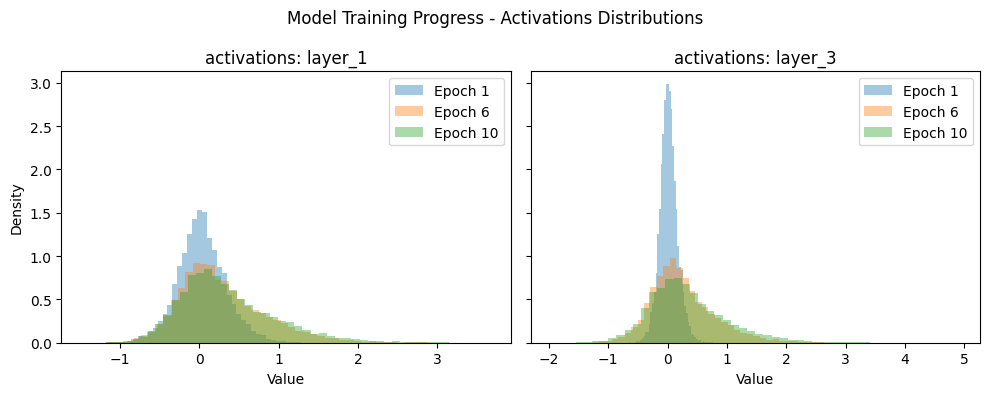

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_history_distributions(history, title_prefix):
    for category, layers in history.items():
        if not layers:
            continue

        num_layers = len(layers)
        fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 4), sharey=True)
        if num_layers == 1: axes = [axes]

        for ax, (layer_name, values_list) in zip(axes, layers.items()):
            if len(values_list) == 0:
                continue

            # Dynamically determine which epochs to show based on availability
            indices = sorted(list(set([0, len(values_list) // 2, len(values_list) - 1])))

            for i in indices:
                if 0 <= i < len(values_list):
                    ax.hist(values_list[i], bins=50, alpha=0.4, label=f'Epoch {i+1}', density=True)

            ax.set_title(f"{category}: {layer_name}")
            ax.legend()
            ax.set_xlabel("Value")
            if ax == axes[0]: ax.set_ylabel("Density")

        plt.suptitle(f"{title_prefix} - {category.capitalize()} Distributions")
        plt.tight_layout()
        plt.show()

# Visualize the captured history
plot_history_distributions(model.history, "Model Training Progress")

In [17]:
print("--- Gradient Statistics (Last Epoch) ---")
for layer_name, grad_list in model.history['gradients'].items():
    if grad_list:
        last_grad = grad_list[-1]
        print(f"{layer_name} | Mean: {np.mean(last_grad):.2e} | Std: {np.std(last_grad):.2e} | Max: {np.max(np.abs(last_grad)):.2e}")

--- Gradient Statistics (Last Epoch) ---
linear_relu_stack.0.weight | Mean: -8.74e-05 | Std: 1.54e-03 | Max: 1.49e-02
linear_relu_stack.2.weight | Mean: -6.85e-05 | Std: 2.21e-03 | Max: 2.48e-02
linear_relu_stack.4.weight | Mean: 1.12e-09 | Std: 2.42e-02 | Max: 2.09e-01


1. **Scale**: The standard deviations and max values (ranging from $1.5 * 10^{-3}$ to $2.5 * 10^{-2}$) indicate that the gradients are large enough to facilitate learning but not so large that they would cause instability.
2. **No Vanishing Gradients**: Even in the earlier layers (linear_relu_stack.0), the gradients haven't 'vanished' to near-zero levels ($10^{-7}$ or smaller).
3. **Layer Progression**: It is normal for the final layer (linear_relu_stack.4) to have slightly larger gradients as it receives the error signal first during backpropagation.

In [18]:
print("--- Final Epoch Activation Statistics ---")
for layer_name, values_list in model.history['activations'].items():
    last_epoch_act = values_list[-1]
    mean_act = np.mean(last_epoch_act)
    std_act = np.std(last_epoch_act)
    dead_neurons = np.sum(last_epoch_act <= 0) / len(last_epoch_act) * 100
    print(f"{layer_name} | Mean: {mean_act:.4f} | Std: {std_act:.4f} | Zero/Negative: {dead_neurons:.1f}%")

--- Final Epoch Activation Statistics ---
layer_1 | Mean: 0.3481 | Std: 0.6016 | Zero/Negative: 30.6%
layer_3 | Mean: 0.3360 | Std: 0.6673 | Zero/Negative: 32.4%


1. **Weights Distribution**: Shows how the weight values for each linear layer evolve. Usually, these spread out slightly as the model learns.
2. **Gradients Distribution**: This is crucial for checking for vanishing or exploding gradients. You want to see these centered around zero but with enough variance to indicate learning is happening.
3. **Activations Distribution**: This shows the output of each layer (after the ReLU). It helps you see if your neurons are 'dead' (all at zero) or if they are providing a healthy range of values.

# Saving Models

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

# Loading Models

In [ ]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()  # Set the module in evaluation mode. This has an effect only on certain modules, e.g. Dropout, BatchNorm etc.
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device).unsqueeze(0) # Add batch dimension
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')